<a href="https://colab.research.google.com/github/LiliaCN/BestPractices/blob/master/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pymatgen cbfv nomad-lab

In [2]:
import pymatgen.core as mg

In [3]:
!pip install cbfv

In [4]:
!pip list

Package                               Version
------------------------------------- ------------------
absl-py                               1.4.0
accelerate                            1.14.0
access                                1.1.10.post3
affine                                3.0.1
aiobotocore                           3.9.1
aiofiles                              25.1.0
aiohappyeyeballs                      2.7.1
aiohttp                               3.14.3
aioitertools                          0.13.0
aiosignal                             1.4.0
aiosqlite                             0.22.1
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.12.1
altair                                5.5.0
annotated-doc                         0.0.5
annotated-types                       0.8.0
antlr4-python3-runtime                4.9.3
anyio                                 4.14.2
an

In [5]:
!pip install mp-api

  Using cached botocore-1.43.93-py3-none-any.whl.metadata (5.6 kB)
Using cached botocore-1.43.93-py3-none-any.whl (15.8 MB)
  Attempting uninstall: botocore
    Found existing installation: botocore 1.43.75
    Uninstalling botocore-1.43.75:
      Successfully uninstalled botocore-1.43.75
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 3.9.1 requires botocore<1.43.76,>=1.43.66, but you have botocore 1.43.93 which is incompatible.


In [6]:
import CBFV

In [7]:
from mp_api.client import MPRester


LiliaCN_API = "4aeVCH4Q9LwHNzSKm6iiZYr4Xo93Dpym"



In [8]:
with MPRester(LiliaCN_API) as mpr:   # use this for Automatic Resource Management: The with statement ensures that the connection session is properly opened when you enter the block and—more importantly—closed automatically when you exit.

# TASK 1: Retrieve the crystal structure for a specific material by its Materials Project ID
    material_id = "mp-2534"  # Example material ID for GaAs
        # Fetch structure for the material
    structure = mpr.get_structure_by_material_id(material_id)
        # Print fetched data
    print(f"--Structure:--\n {structure}")

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

--Structure:--
 Full Formula (Ga1 As1)
Reduced Formula: GaAs
abc   :   4.065993   4.065993   4.065993
angles:  59.999991  59.999992  59.999994
pbc   :       True       True       True
Sites (2)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Ga    0     0     0
  1  As    0.25  0.25  0.25


In [9]:
#Task 1.2: Query Be-Containing Materials
with MPRester(LiliaCN_API) as mpr:
  summary_subrester = mpr.materials.summary  # Sub-Resters are usually attributes of MPRester

  results = summary_subrester.search(elements=["Be"], # Be or Mg are required, but other elements also allowed
                                       density=(2.0, 4.0),   #g/cm3
                                       band_gap=(0.5, 3.0))  # band gap from 0.5 - 1.0 eV
  results += summary_subrester.search(elements=["Mg"], # Be or Mg are required, but other elements also allowed
                                       density=(2.0, 4.0),   #g/cm3
                                       band_gap=(0.5, 3.0))  # band gap from 0.5 - 1.0 eV
  print(f"The number of returned materials is: {len(results)}")


Retrieving SummaryDoc documents:   0%|          | 0/76 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/2333 [00:00<?, ?it/s]

The number of returned materials is: 2409


In [10]:
#Task 1.3: Identify Highest Band Gap Material
mp_bandgaps = [doc.band_gap for doc in results]
#print(results[0].formula_pretty)
#print(f"First 5 bandgaps: {mp_bandgaps[:5]}")
#print(type(mp_bandgaps))
max_bg = max(mp_bandgaps)
max_pos = mp_bandgaps.index(max_bg)
#print(max_pos)
print(results[max_pos].formula_pretty, ": bandgap = ", max_bg)



Na8Y2Mg2Si3(SO8)3 : bandgap =  2.9958000000000005


In [11]:
#Task 1.4: Check Material Stability
print(results[max_pos].is_stable)
#mp_stable = [doc.is_stable for doc in results]
#print(mp_stable)
sorted_list = sorted(mp_bandgaps, reverse=True)
print(sorted_list)

print("and...")
print(mp_bandgaps)
print(len(sorted_list))
max_stable_found = False

for i in range(len(sorted_list)):
  pos = mp_bandgaps.index(sorted_list[i])
  if results[pos].is_stable == True:
    res = sorted_list[i]
    max_stable_found = True
    break
if max_stable_found == False:
  print("No stable material found")
else:
  print(results[pos].formula_pretty, ": bandgap = ", res)
  print(results[pos].is_stable)



False
[2.9958000000000005, 2.9953000000000003, 2.9911, 2.9898000000000002, 2.9891000000000005, 2.9889, 2.9885, 2.9880999999999998, 2.9868999999999994, 2.9861, 2.9852, 2.9851999999999994, 2.984, 2.9775, 2.9745, 2.9736000000000002, 2.9730000000000003, 2.9720000000000004, 2.9715, 2.9713000000000003, 2.971, 2.9702, 2.9691000000000005, 2.9668, 2.9662000000000006, 2.963, 2.9629000000000003, 2.9627999999999997, 2.9585999999999997, 2.9558999999999997, 2.9549000000000003, 2.9543999999999997, 2.9495999999999993, 2.9492000000000003, 2.9482999999999997, 2.9473, 2.9453, 2.9451, 2.9427, 2.9417, 2.9402, 2.9396999999999998, 2.9391, 2.9354999999999998, 2.9328, 2.9288000000000003, 2.9277999999999995, 2.9267, 2.9265000000000003, 2.9264, 2.9242, 2.9234, 2.923, 2.9224, 2.9212999999999996, 2.9212, 2.92, 2.9181, 2.9172000000000002, 2.9164, 2.9159000000000006, 2.9149, 2.9145, 2.9141000000000004, 2.9136, 2.9120999999999997, 2.9101999999999997, 2.9092, 2.9081, 2.9046999999999996, 2.9006999999999996, 2.894700000

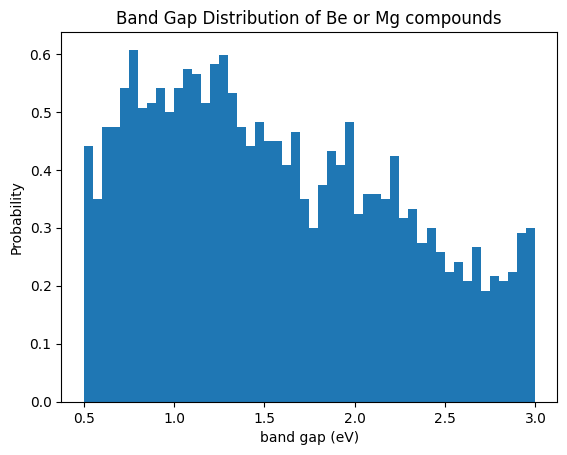

In [12]:
#Task 1.5: Visualize Band Gap Distribution
import matplotlib.pyplot as plt
plt.clf()         		#cleans any previous formatting of the graph
plt.hist(mp_bandgaps, density=True, bins=50)
plt.xlabel('band gap (eV)')
plt.ylabel('Probability')
plt.title('Band Gap Distribution of Be or Mg compounds')
plt.savefig('BandgapBeMg.png', dpi=300, bbox_inches='tight')

In [13]:
#Task 1.6: Create DataFrame
import pandas as pd
print(type(results))
mp_form = [doc.formula_pretty for doc in results]
print(mp_form)
df_form_bg = pd.DataFrame(list(zip(mp_form, mp_bandgaps )), columns = ['Formula', 'Bandgap'])
print(df_form_bg.head(10))
print(df_form_bg.shape)

<class 'list'>
['BeCrO4', 'BeCrO4', 'BeCrO4', 'BeSiP2', 'BeSnP2', 'BeGeP2', 'CaBeAsO5', 'MnBePO5', 'CaBePO5', 'LiBeAsO5', 'TmBeNF6', 'Rb8Zr6BeBr20', 'Rb3Zr6BeCl15', 'LuBeNF6', 'K3Zr6BeCl15', 'K8Zr6BeBr20', 'HoBeNF6', 'ErBeNF6', 'BeSiN2', 'BeZnS2', 'BeZn3S4', 'LiBeAs', 'NaBeAs', 'NaBeSb', 'LiBeP', 'BeP2', 'K2BeO2', 'Na2BeO2', 'K4BeAs2', 'Na2BeSiO4', 'Ba3Zr6BeCl18', 'KNaZr2Be(PO4)4', 'NaBeSi3O8', 'NaBeO2', 'Na6BeO4', 'Ca(BeP)2', 'Mg(BeP)2', 'Ca(BeAs)2', 'Be2SiO4', 'K2Be2Ni(O3F4)2', 'K2Be2NiH6F8', 'Ca4Be2Al2Si9O28', 'Be2CoH6(NF4)2', 'Be2Tl2Ni(O3F4)2', 'Be2Co(NF7)2', 'Ca2Be2P2O9F', 'Be2Co(NF7)2', 'Be2C', 'Ca(BeN)2', 'Sr(BeN)2', 'K2Na4Be2O5', 'Ca3TiBe2Si2(As3O10)2', 'Rb2Be2O3', 'Be3Si3(SbO6)2', 'Be3Si3(SnO6)2', 'Be3Fe2(SiO4)3', 'Be3Cr2(SiO4)3', 'Be3V2(SiO4)3', 'CaBe3Co2(SiO4)3', 'Be3N2', 'NaBe3Al2Si6O19', 'Na3Be3B3P6O25', 'Be3Si3C4SO12', 'Be3ZnS4', 'Ca4Be3AlSi9(HO14)2', 'Be3Si3(SnO6)2', 'Mn4Be3Si3TeO12', 'Mn4Be3Si3SeO12', 'Mn4Be3Ge3SeO12', 'Mn4Be3Ge3SO12', 'Be3P2', 'Be3Fe4Si3SO12', 'Be3Al2S

In [14]:
#Task 1.7: Copy and Explore Data
copyFBg = df_form_bg.copy()
print(copyFBg.head(10))

    Formula  Bandgap
0    BeCrO4   2.4299
1    BeCrO4   2.2720
2    BeCrO4   2.0973
3    BeSiP2   1.1502
4    BeSnP2   0.9223
5    BeGeP2   0.9023
6  CaBeAsO5   0.6159
7   MnBePO5   2.0660
8   CaBePO5   0.5856
9  LiBeAsO5   1.0529


In [15]:
#Task 1.8: Identify Duplicates
duplicates = copyFBg[copyFBg.duplicated()]
print(duplicates)
print('The number of duplicat rows is ', len(duplicates))

       Formula  Bandgap
1047  Mg(BeP)2   0.6341
The number of duplicat rows is  1


In [16]:
#Task 1.9: Remove Duplicate Rows
print(copyFBg.shape)
copyFBg.drop_duplicates(inplace=True)
print(copyFBg.shape)


(2409, 2)
(2408, 2)


In [17]:
#Task 1.10: Handle Formula Duplicates
# take the average value of all duplicate formulas and replace the duplicate
# formulas with the average bandgap value.
unduplFBg = copyFBg.groupby('Formula', as_index=False)['Bandgap'].mean()
print(unduplFBg.shape)

(1505, 2)


In [18]:
#Task 1.11: Validate Averaging
# Find all rows where the formula appears more than once
duplicates = copyFBg[copyFBg.duplicated(subset=['Formula'], keep=False)]

# Sort by formula so the duplicates are grouped together next to each other
duplicates_sorted = duplicates.sort_values(by='Formula')

print(duplicates_sorted)
import numpy as np
def CalcMean(form):
  bg = copyFBg[copyFBg['Formula'] == form]
  mean = np.average(bg['Bandgap'])
  res = 'For ' + form + ' the average bandgap is ' + str(mean)
  return res
print(CalcMean('Ba2MgMn2(P2O7)2'))

print(unduplFBg[unduplFBg['Formula']=='Ba2MgMn2(P2O7)2'])

              Formula  Bandgap
1296  Ba2MgMn2(P2O7)2   1.1157
1419  Ba2MgMn2(P2O7)2   1.1099
1329  Ba2MgMn2(P2O7)2   1.9981
1310  Ba2MgMo4(P2O7)4   2.2342
1463  Ba2MgMo4(P2O7)4   2.1634
...               ...      ...
1261           Y2MgS4   1.5444
1231           Y2MgS4   1.9492
1232           Y2MgS4   2.9453
1233           Y2MgS4   2.5767
1039           Y2MgS4   1.7768

[1325 rows x 2 columns]
For Ba2MgMn2(P2O7)2 the average bandgap is 1.4079000000000004
           Formula  Bandgap
3  Ba2MgMn2(P2O7)2   1.4079


**Part 2: Featurization and Machine Learning**

In [19]:
#Task 2.1: Import CBFV
#Note: There are a few different featurizers that can be used: oliynyk (default), onehot, mat2vec
from CBFV import composition
print("Columns before featurization:", unduplFBg.shape)
# rename columns to match CBFV criteria
unduplFBg.columns = ['formula', 'target']

print(unduplFBg.head())

try:
    # 2. Generate features using the default 'magpie' schema
    X, y, formulae, skipped = composition.generate_features(unduplFBg, elem_prop='magpie')

    print("\n--- CBFV Status: WORKING! ---")
    print(f"Successfully processed {len(formulae)} formulas.")
    print(f"Generated feature matrix (X) shape: {X.shape}")
    print(f"Target vector (y) shape: {y.shape}")
    print("\nFirst few columns of the generated features:")
    print(X.iloc[:, :5].head())

except Exception as e:
    print("\n--- CBFV Status: FAILED ---")
    print(f"Error encountered: {e}")


/usr/local/lib/python3.13/dist-packages/CBFV/composition.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Columns before featurization: (1505, 2)
           formula  target
0         Ba(MgP)2  1.1366
1     Ba2Mg(TiS3)2  0.6783
2          Ba2MgH6  2.8864
3  Ba2MgMn2(P2O7)2  1.4079
4  Ba2MgMo4(P2O7)4  2.1067


Processing Input Data: 100%|██████████| 1505/1505 [00:00<00:00, 3254.96it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 1505/1505 [00:00<00:00, 1599.18it/s]


	Creating Pandas Objects...

--- CBFV Status: WORKING! ---
Successfully processed 1505 formulas.
Generated feature matrix (X) shape: (1505, 132)
Target vector (y) shape: (1505,)

First few columns of the generated features:
   avg_Number  avg_MendeleevNumber  avg_AtomicWeight  avg_MeltingT  avg_Column
0   22.000000            62.200000         49.576905    696.120000    7.200000
1   24.000000            63.636364         53.371182    830.469091   10.000000
2   14.444444            70.888889         33.889627    334.117778    1.333333
3   15.043478            75.652174         32.900945    347.713043   13.217391
4   14.790698            78.744186         32.059821    432.088372   13.906977


In [20]:
#Task 2.2: Prepare Datasets
print(type(X.iloc[:, :5]))
print(type(y))
print(type(formulae))
print(type(skipped))

df_oli, y_oli, formulae_oli, skipped_oli = composition.generate_features(unduplFBg, elem_prop='oliynyk')
df_onehot, y_onehot, formulae_onehot, skipped_onehot  = composition.generate_features(unduplFBg, elem_prop='onehot')
df_mat2vec, y_mat2vec, formulae_mat2vec, skipped_mat2vec = composition.generate_features(unduplFBg, elem_prop='mat2vec')


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'list'>


Processing Input Data: 100%|██████████| 1505/1505 [00:00<00:00, 3505.99it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 1505/1505 [00:00<00:00, 4475.44it/s]


	Creating Pandas Objects...


...

	Creating Pandas Objects...


Processing Input Data: 100%|██████████| 1505/1505 [00:00<00:00, 6152.67it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 1505/1505 [00:00<00:00, 3860.27it/s]


	Creating Pandas Objects...


In [21]:
print(df_oli.shape)
print(df_onehot.shape)
print(df_mat2vec.shape)

print(y_oli.head())

(1505, 264)
(1505, 714)
(1505, 1200)
0    1.1366
1    0.6783
2    2.8864
3    1.4079
4    2.1067
Name: target, dtype: float64


In [22]:
print(y_onehot.head())

0    1.1366
1    0.6783
2    2.8864
3    1.4079
4    2.1067
Name: target, dtype: float64


In [23]:
print(y_mat2vec.head())

0    1.1366
1    0.6783
2    2.8864
3    1.4079
4    2.1067
Name: target, dtype: float64


In [24]:
#Task 2.4: Train and Evaluate Models
from sklearn.model_selection import train_test_split

# Set a random seed to ensure reproducibility across runs
RNG_SEED = 13
np.random.seed(seed=RNG_SEED)

#Split the data
X_train_oli, X_test_oli, y_train_oli, y_test_oli = train_test_split(df_oli, y_oli, test_size=0.20, random_state=RNG_SEED)
X_train_onehot, X_test_onehot, y_train_onehot, y_test_onehot = train_test_split(df_onehot, y_onehot, test_size=0.20, random_state=RNG_SEED)
X_train_mat2vec, X_test_mat2vec, y_train_mat2vec, y_test_mat2vec = train_test_split(df_mat2vec, y_mat2vec, test_size=0.20, random_state=RNG_SEED)

# Train 3 random forest regressors (one for each featurized dataset)
from sklearn.ensemble import RandomForestRegressor
RF_model_oli = RandomForestRegressor()
RF_model_oli.fit(X_train_oli, y_train_oli)

RF_model_onehot = RandomForestRegressor()
RF_model_onehot.fit(X_train_onehot, y_train_onehot)

RF_model_mat2vec = RandomForestRegressor()
RF_model_mat2vec.fit(X_train_mat2vec, y_train_mat2vec)


RandomForestRegressor()

In [25]:
# Evaluate the models using MSE
from sklearn.metrics import mean_squared_error
y_pred_oli = RF_model_oli.predict(X_train_oli)
print(y_pred_oli.shape)
print(type(y_pred_oli))
print(y_train_oli.shape)
print(type(y_train_oli))
MSE_oli = mean_squared_error(y_train_oli, y_pred_oli)
print("MSE for oliynyk: ", MSE_oli)

y_pred_onehot = RF_model_onehot.predict(X_train_onehot)
MSE_onehot = mean_squared_error(y_train_onehot, y_pred_onehot)
print("MSE for onehot: ", MSE_onehot)

y_pred_mat2vec = RF_model_mat2vec.predict(X_train_mat2vec)
MSE_mat2vec = mean_squared_error(y_train_mat2vec, y_pred_mat2vec)
print("MSE for mat2vec: ", MSE_mat2vec)

(1204,)
<class 'numpy.ndarray'>
(1204,)
<class 'pandas.core.series.Series'>
MSE for oliynyk:  0.0440490199170881
MSE for onehot:  0.044368972453100085
MSE for mat2vec:  0.04532253962656691


MSE for oliynyk test data:  0.2825250023489667
MSE for onehot test data:  0.2868624820776155
MSE for mat2vec test data:  0.2948834151657557


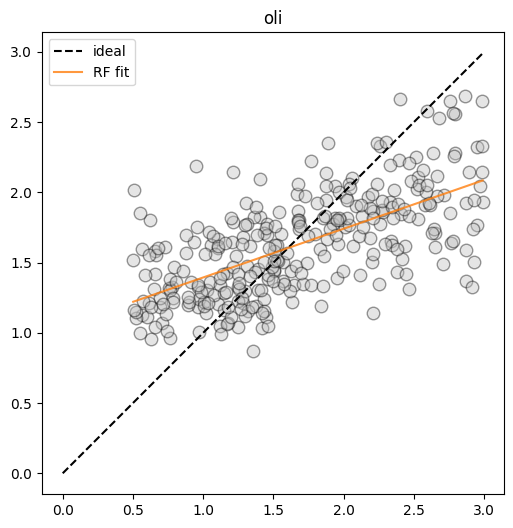

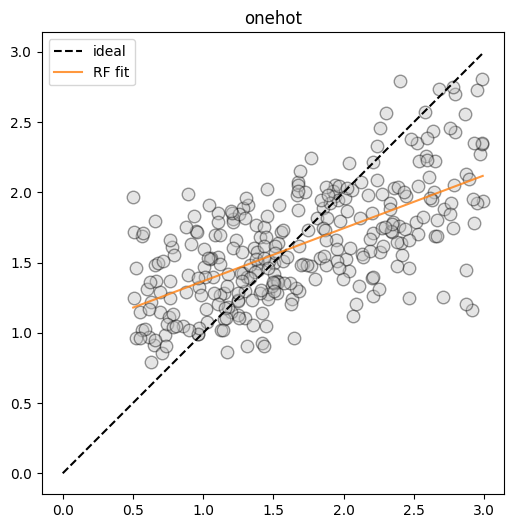

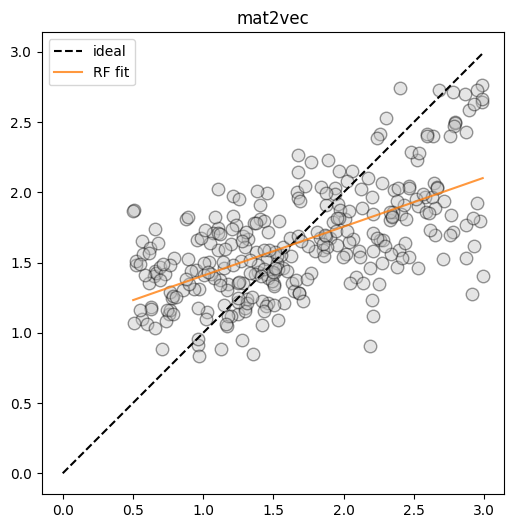

In [26]:
#Task 2.5.1 Evaluate test error
y_predtest_oli = RF_model_oli.predict(X_test_oli)
MSE_olitest = mean_squared_error(y_test_oli, y_predtest_oli)
print("MSE for oliynyk test data: ", MSE_olitest)

y_predtest_onehot = RF_model_onehot.predict(X_test_onehot)
MSE_onehottest = mean_squared_error(y_test_onehot, y_predtest_onehot)
print("MSE for onehot test data: ", MSE_onehottest)

y_predtest_mat2vec = RF_model_mat2vec.predict(X_test_mat2vec)
MSE_mat2vec = mean_squared_error(y_test_mat2vec, y_predtest_mat2vec)
print("MSE for mat2vec test data: ", MSE_mat2vec)

#plot predictions
def plot_pred_act(act, pred, model, reg_line=True):
    xy_max = np.max([np.max(act), np.max(pred)])

    plot = plt.figure(figsize=(6,6))
    plt.plot(act, pred, 'o', ms=9, mec='k', mfc='silver', alpha=0.4)
    plt.plot([0, xy_max], [0, xy_max], 'k--', label='ideal')
    if reg_line:
        polyfit = np.polyfit(act, pred, deg=1)
        reg_ys = np.poly1d(polyfit)(np.unique(act))
        plt.plot(np.unique(act), reg_ys, alpha=0.8, label='RF fit')
    plt.axis('scaled')
    #plt.xlabel(f'Actual {label}')
    #plt.ylabel(f'Predicted {label}')
    plt.title(f'{model}')
    plt.legend(loc='upper left')

    return plot

plotoli = plot_pred_act(y_test_oli, y_predtest_oli, 'oli', reg_line=True)
plotoh = plot_pred_act(y_test_onehot, y_predtest_onehot, 'onehot', reg_line=True)
plotm2v = plot_pred_act(y_test_mat2vec, y_predtest_mat2vec, 'mat2vec', reg_line=True)

Task 2.5: Model Comparison
The performances are quite similar. They all seem not to capture well the bandgaps, as the slopes of the predicted values are not 45°. The errors are also at the same range. Olylink has slightly smaller MSE. So, Olylink has performed best.

**Part 3: Data Repository Integration - NOMAD**

In [27]:
#Task 3.1: Setup NOMAD Access
#pip install nomad-lab       #jà fiz là em cima

# Install required packages
# Note: requests, pandas, numpy, matplotlib are pre-installed in Colab
# We only need to install nomad-lab if required
# Using regular pip to avoid build issues
!pip install nomad-lab --quiet 2>/dev/null || echo "nomad-lab installation skipped"

In [28]:
#test NOMAD installation
import requests
import json

#Access data using NOMAD API access
# NOMAD API base URL  NEW
BASE_URL = "https://nomad-lab.eu/prod/v1/api/v1"

# Headers for requests (only Accept header for GET requests)
headers = {
    'Accept': 'application/json',
    'Content-Type': 'application/json'
}

# Payload structure mapping query requirements to the current metadata schema
payload = {
    "query": {    #query Filters the database
        "results.material.elements": {
            "any": ["Si"]
        }
    },
    "pagination": {           #pagination: Controls how much data comes back.
        "page_size": 10        #page_size:  limit the response to 10 entries.
    }
}

# Using the HTTP POST method to query entries in NOMAD v1 (the new one)
response = requests.post(f"{BASE_URL}/entries/query", headers=headers, json=payload)
print(f"Test query status: {response.status_code}")
print(f"Request URL: {response.url}\n")

if response.status_code == 200:
    test_data = response.json()
    # Show what's actually in the response
    print(f"Response keys: {list(test_data.keys())}")
    #print(test_data)

    # Check each key to see what contains the entries
    for key in test_data.keys():
        value = test_data[key]
        print('if 1')
        if isinstance(value, list):

            print(f"  '{key}': value is a list with {len(value)} key items")
            if len(value) > 0:
                print(f"    First key item type: {type(value[0])}")
                print('value[0] = ', value[0])
                if isinstance(value[0], dict):
                    print(f"    First item keys: {list(value[0].keys())}")
                    quantities0 = value[0].get('quantities')
                    print(f"    quantities0 type: {type(quantities0)}")
                    print(f"    First key item quantities: {quantities0}")
                    #print(f"    First key item res mat: {quantities0.get('results.material')}")
                else:
                    print(f"    First key item : {value[0]}")
        elif isinstance(value, dict):
            print(f"  '{key}': dict with keys: {list(value.keys())[:5]}")
        else:
            print(f"  '{key}': {type(value).__name__}")
    print(f"    First key item: {test_data}")

    # Try to find the entries
    print("\n" + "="*60)
    if 'data' in test_data and isinstance(test_data['data'], list):
        results = test_data['data']
        print(f"    data results type: {type(results)}")
        print(f"    First data item : {results}")
        print(f"Found entries in 'results': {len(results)} entries")
        if len(results) > 0:
            first = results[0]
            print(f"\nFirst data entry ID: {first.get('upload_id', 'N/A')}")
            #print(f"First data entry keys: {list(first.keys())[:15]}")
            print(f"First data entry keys: {list(first.keys())}")

    elif isinstance(test_data, list):
        print(f"Response is directly a list: {len(test_data)} entries")
        if len(test_data) > 0:
            print(f"First entry keys: {list(test_data[0].keys())[:15]}")
    else:
        print("Could not locate entries in response")
        print("\nFull response structure:")
        print(json.dumps(test_data, indent=2)[:1500])

else:
    print(f"Error fetching data: {response.text}")

Test query status: 200
Request URL: https://nomad-lab.eu/prod/v1/api/v1/entries/query

Response keys: ['owner', 'query', 'pagination', 'data']
if 1
  'owner': str
if 1
  'query': dict with keys: ['name', 'value']
if 1
  'pagination': dict with keys: ['page_size', 'order_by', 'order', 'total', 'next_page_after_value']
if 1
  'data': value is a list with 10 key items
    First key item type: <class 'dict'>
value[0] =  {'upload_id': 'lFStf3xORRCCVZhlXAS4_w', 'references': [], 'origin': 'Miguel Marques', 'text_search_contents': [], 'quantities': ['', 'metadata', 'metadata.coauthor_groups', 'metadata.coauthors', 'metadata.datasets', 'metadata.domain', 'metadata.embargo_length', 'metadata.entry_coauthors', 'metadata.entry_create_time', 'metadata.entry_hash', 'metadata.entry_id', 'metadata.entry_name', 'metadata.entry_timestamp', 'metadata.entry_timestamp.timestamp', 'metadata.entry_timestamp.token', 'metadata.entry_timestamp.token_seed', 'metadata.entry_timestamp.tsa_server', 'metadata.entry

**Testing the API**
First, let's test if the API is working with a simple query.

Note: If the test returns a count but empty data:
- The API may require authentication or specific parameters
- Some entries may be restricted or not publicly accessible
- The API response structure may have changed
- Try checking the full response JSON to see what's included

In [29]:
#Task 3.2: Browse NOMAD Database
# Search for Be-containing materials
# Using 'results.material.elements' to filter by element

# 1. Update the payload structure with the "required" metadata inclusions
payload = {
    "query": {
        "results.material.elements": {
            "any": ["Be"]
        }
    },
    "pagination": {
        "page_size": 10
    }
}

# Send the API request
response = requests.post(f"{BASE_URL}/entries/query", headers=headers, json=payload)
print(f"Response status: {response.status_code}")
print(f"Request URL: {response.url}")
#print('dump',json.dumps(response.json(), indent=2))

if response.status_code == 200:
    data = response.json()
    # Show what's actually in the response
    print(f"Response keys: {list(data.keys())}")
    print('owner: ', data['owner'])
    print('query: ', data['query'])
    print('pagination: ', data['pagination'])
    print(type(data['pagination']))
    total = data.get('pagination', [])
    print('total: ', total['total'])

    entries = data.get('data', [])
    print('data: ', entries)
    print(f"\nShowing {len(entries)} results:")

    for entry in entries:
        entry_id = entry.get('entry_id', 'N/A')

        # Access the objects via their specific included paths
        results_block = entry.get('results', {})
        material_block = results_block.get('material', {})
        formula = material_block.get('chemical_formula_reduced', 'N/A')
        elements = material_block.get('elements', [])
        symmetry = material_block.get('symmetry', [])
        crystal = symmetry.get('crystal_system', [])

        properties_block = results_block.get('properties', {})
        available_properties = properties_block.get('available_properties', [])

        print(f"  Entry: {entry_id} -> Formula: {formula} Available Properties: {available_properties} Elements: {elements}")
        print(f"  Formula: {formula} - > Crystal System: {crystal}")
else:
    print(f"\nError {response.status_code}: {response.text}")



Response status: 200
Request URL: https://nomad-lab.eu/prod/v1/api/v1/entries/query
Response keys: ['owner', 'query', 'pagination', 'data']
owner:  public
query:  {'name': 'results.material.elements', 'value': {'any': ['Be']}}
pagination:  {'page_size': 10, 'order_by': 'entry_id', 'order': 'asc', 'total': 646863, 'next_page_after_value': '--4m5bh2SQpqlUZZaAb1drOa9IHT'}
<class 'dict'>
total:  646863
data:  [{'upload_id': 'EeJ71qJ5Tl2eklag1b_Oow', 'references': [], 'origin': 'Miguel Marques', 'text_search_contents': [], 'quantities': ['', 'metadata', 'metadata.coauthor_groups', 'metadata.coauthors', 'metadata.datasets', 'metadata.domain', 'metadata.embargo_length', 'metadata.entry_coauthors', 'metadata.entry_create_time', 'metadata.entry_hash', 'metadata.entry_id', 'metadata.entry_name', 'metadata.entry_timestamp', 'metadata.entry_timestamp.timestamp', 'metadata.entry_timestamp.token', 'metadata.entry_timestamp.token_seed', 'metadata.entry_timestamp.tsa_server', 'metadata.entry_type', 'm

In [30]:
#Learning from the NOMAD website https://docs.nomad-lab.eu/howto/manage/program/archive_query.html#a-complete-rundown
from nomad.client.archive import ArchiveQuery

required = {
    'workflow': {
        'calculation_result_ref': {
            'energy': '*',
            'system_ref': {
                'chemical_composition_reduced': '*'
            }
        }
    }
}
query = {
        "results.material.elements": ["Be"]
        }

query = ArchiveQuery(query=query, required=required, page_size=10, results_max=100)
query.fetch(10)
print(query.entry_list())

# 2. Fetch and download the entries from the server first
result = query.download(7)          #saves 7 entries to result and removes the 9 entries from query.entry_list()
print(f'Downloaded {len(result)} entries.')
print(query.entry_list())            #now it has only 3 entries left
print(query)
print(result)
print(result[0])



Fetching remote uploads...
10 entries are qualified and added to the download list.
[('--0Hj5fqGLafCh90yCg1gBBRRlKo', 'wc3s1vsdTaO3UWbLKvyDZQ'), ('--19lZvxD_bLohC4j4QeQDVUt5FR', 'HtHJLMa0Q_WNi4CzR8TwQg'), ('--1E-2uAJabaWqhog1P1aPV6HPED', 'VdEFaQgfTFKSoxOn0cMSzA'), ('--1tF2pYwNHN-rypJ5e-eG-MqfOx', 'ZJQAsQgoTBaqNU36mXMf4g'), ('--3xxzC8YfR_bak3RgX_AKkvFFgB', 'N6XpgzNsRoqFIpJb-VnB5g'), ('--44lFEnBMWBfRvPcS-qjkXaA59l', 'fU73G3VZQ3m2yu3Pasn1rg'), ('--4m5bh2SQpqlUZZaAb1drOa9IHT', 'SBgRfO86T8OFvmy4TCnEIw'), ('--5AEJ9t4S3wDHg5NVvuuLygpQnP', 'cBHv2LS0Tf2268TrDiRQ4A'), ('--7VDlGOvaXtZonQBSftL0XWR4Kd', '_X9wmh6RSfC8FcPL_8s5Tg'), ('--8DKhHVMNAaAqTiakn6YO7fnJ6U', 'yNgGjXLoQ3CnZxcLTxO7JQ')]
Downloaded 7 entries.
[('--5AEJ9t4S3wDHg5NVvuuLygpQnP', 'cBHv2LS0Tf2268TrDiRQ4A'), ('--7VDlGOvaXtZonQBSftL0XWR4Kd', '_X9wmh6RSfC8FcPL_8s5Tg'), ('--8DKhHVMNAaAqTiakn6YO7fnJ6U', 'yNgGjXLoQ3CnZxcLTxO7JQ')]
[EntryArchive(workflow), EntryArchive(), EntryArchive(), EntryArchive(), EntryArchive(), EntryArchive(), EntryAr

In [31]:
import requests
import json
import pandas as pd

#Access data using NOMAD API access
# NOMAD API base URL  NEW
BASE_URL = "https://nomad-lab.eu/prod/v1/api/v1"

# Headers for requests (only Accept header for GET requests)
headers = {
    'Accept': 'application/json',
    'Content-Type': 'application/json'
}

# Define the query payload
payload = {
    "query": {
        "results.material.elements": {"all": ["Be", "O"]}
    },
    "pagination": {
        "page_size": 10000  # # Fetching in  batches of nn
    }
}

print("Querying NOMAD API v1...")
response = requests.post(f"{BASE_URL}/entries/query", headers=headers, json=payload)
print(f"Test query status: {response.status_code}")

if response.status_code == 200:
    data = response.json()
    # Show what's actually in the response
    print(f"Response keys: {list(data.keys())}")
    total = data.get('pagination', [])
    print('total: ', total['total'])
    '''
    ## 💾 SAVE TO JSON FILE
    # the raw, deeply nested JSON structure that the NOMAD API originally sent back. For 99% of data science and machine learning workflows, saving the flat DataFrame version is exactly what you want.
    json_filename = "nomad_BeO_data.json"
    with open(json_filename, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)
    print(f"Success! Raw API response saved locally as '{json_filename}'\n")
    '''
    #Store the data in a structured format (DataFrame)
    # Parse the results into a flat list
    flattened_data = []
    for entry in data.get("data", []):
        entry_id = entry.get('entry_id', 'N/A')  #<class 'str'>
        results = entry.get("results", {})    #<class 'dict'>
        material = results.get("material", {})    #<class 'dict'>
        properties = results.get("properties", {})    #<class 'dict'>

        # Safely extract electronic band gap list
        electro = properties.get("electronic", {})
        band_gap = electro.get("band_gap", [])
        # Get the value of the first band gap if available
        bg_valueJ = band_gap[0]['value'] if band_gap else None
        # Automatically convert to eV if a value exists
        bg_eV = bg_valueJ / 1.602176634e-19 if bg_valueJ is not None else None

        # Safely extract structures list
        structures = properties.get("structures", {})
        #print('structures', structures)
        structure_primitive = structures.get("structure_primitive", {})
        #print('structure_primitive', structure_primitive)
        # Get the value of the cell volume if available
        cell_volume  = structure_primitive.get("cell_volume", None)
        #print('cell_volume ', cell_volume )

        row = {
        "chemical_formula_reduced": material.get("chemical_formula_reduced", 'N/A'),
        "elements": material.get("elements", 'N/A'),
        "bandgap_eV": bg_eV,
        "cell_volume": cell_volume
            }
        #print(row)

        flattened_data.append(row)

    # Create Pandas DataFrame
    df = pd.DataFrame(flattened_data)
    print(f"-> Successfully built DataFrame with shape: {df.shape}")
    print(df.describe())
    print(df.columns)

    # Save the complete DataFrame to a clean JSON  file
    df.to_json("nomad_flat_data.json", orient="records", indent=4)
    print("-> Successfully saved the DataFrame to 'nomad_flat_data.json'")

    # Display the first few rows
    print(f"Successfully loaded {len(df)} entries into the DataFrame.")
    print(df.head())

else:
    print(f"\nError {response.status_code}: {response.text}")


Querying NOMAD API v1...
Test query status: 200
Response keys: ['owner', 'query', 'pagination', 'data']
total:  18189
-> Successfully built DataFrame with shape: (10000, 4)
        bandgap_eV   cell_volume
count  5266.000000  2.926000e+03
mean      0.847719  8.647223e-29
std       1.700614  9.375418e-29
min       0.000000  6.044446e-30
25%       0.000000  3.901528e-29
50%       0.007100  5.581111e-29
75%       0.399000  9.942045e-29
max       8.960000  1.248027e-27
Index(['chemical_formula_reduced', 'elements', 'bandgap_eV', 'cell_volume'], dtype='object')
-> Successfully saved the DataFrame to 'nomad_flat_data.json'
Successfully loaded 10000 entries into the DataFrame.
  chemical_formula_reduced         elements  bandgap_eV   cell_volume
0                 AlBeO4Sc  [Al, Be, O, Sc]      3.8875           NaN
1                 Ba2BeO6V   [Ba, Be, O, V]      0.0159           NaN
2                BeNa2O4Pd  [Be, Na, O, Pd]      0.4343           NaN
3                      BeO          [Be, 

In [32]:
# Save the complete DataFrame to a clean JSON array file
df.to_json("nomad_flat_data.json", orient="records", indent=4)
print("-> Successfully saved the DataFrame to 'nomad_flat_data.json'")


-> Successfully saved the DataFrame to 'nomad_flat_data.json'


0    False
1    False
2    False
3     True
4    False
Name: bandgap_eV, dtype: bool
DataFrame shape before dropping bg NaNs: (10000, 4)
DataFrame shape after dropping bg NaNs: (5266, 4)
DataFrame shape after dropping cvol NaNs: (2926, 4)
  chemical_formula_reduced         elements  bandgap_eV  cell_volume
0                 AlBeO4Sc  [Al, Be, O, Sc]      3.8875          NaN
1                 Ba2BeO6V   [Ba, Be, O, V]      0.0159          NaN
2                BeNa2O4Pd  [Be, Na, O, Pd]      0.4343          NaN
4                BeCd2GaO4  [Be, Cd, Ga, O]      0.0470          NaN
5                  BeCaO2P   [Be, Ca, O, P]      0.0104          NaN
   chemical_formula_reduced elements  bandgap_eV   cell_volume
3                       BeO  [Be, O]         NaN  1.252779e-29
8                     Be2O2  [Be, O]         NaN  1.329051e-29
11                      BeO  [Be, O]         NaN  1.178698e-29
13                    Be3O3  [Be, O]         NaN  2.592410e-29
14                    Be3O3  [Be

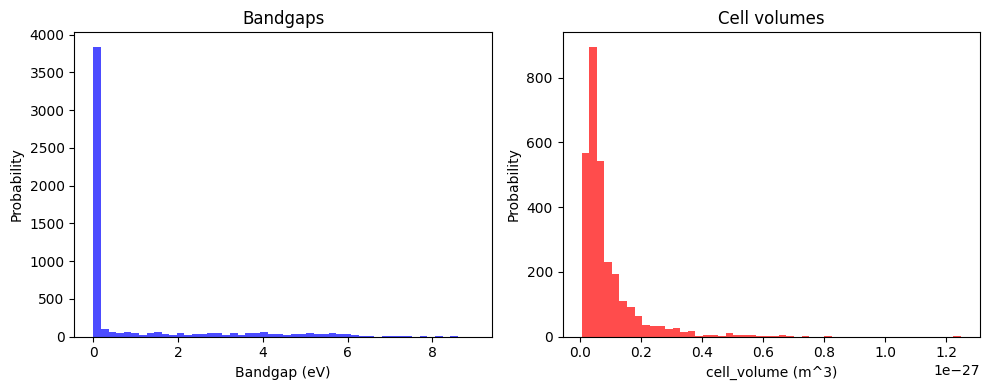

In [33]:
#Visualize data distributions
import matplotlib.pyplot as plt

#Check for and remove NaN values
df2 = df.copy()
bool_nans_bg = df2['bandgap_eV'].isnull()
print(bool_nans_bg.head())

# Drop the rows of the DataFrame which contain bg NaNs
df2 = df2.drop(df2.loc[bool_nans_bg].index, axis=0)
print(f'DataFrame shape before dropping bg NaNs: {df.shape}')
print(f'DataFrame shape after dropping bg NaNs: {df2.shape}')

# Drop the rows of the DataFrame which contain cvol NaNs
df3 = df.copy()
bool_nans_cvol = df['cell_volume'].isnull()
df3 = df3.drop(df.loc[bool_nans_cvol].index, axis=0)

print(f'DataFrame shape after dropping cvol NaNs: {df3.shape}')

print(df2.head())
print(df3.head())

# 1. Create a figure with histograms
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot histograms
ax1.hist(df2['bandgap_eV'], bins=50, alpha=0.7, color='blue')
ax1.set_title('Bandgaps')
ax1.set_xlabel('Bandgap (eV)')
ax1.set_ylabel('Probability')

ax2.hist(df3['cell_volume'], bins=50, alpha=0.7, color='red')
ax2.set_title('Cell volumes')
ax2.set_xlabel('cell_volume (m^3)')
ax2.set_ylabel('Probability')

plt.tight_layout()
plt.savefig('bg_cvol_NOMAD.png', dpi=300, bbox_inches='tight')


In [34]:
#Task 3.4: Compare Data Repositories: Materials Project and NOMAD

#Query Be-Containing Oxides in Materials Project
with MPRester(LiliaCN_API) as mpr:
  summary_subrester = mpr.materials.summary  # Sub-Resters are usually attributes of MPRester
  resultsMP2 = summary_subrester.search(elements=["Be","O"]) # Be and O are required, but other elements also allowed
  print(f"The number of returned materials is: {len(resultsMP2)}")


Retrieving SummaryDoc documents:   0%|          | 0/459 [00:00<?, ?it/s]

The number of returned materials is: 459


[0.0, 1.7691000000000003, 0.0, 2.4299, 1.7507000000000001, 2.1275, 5.3704, 0.0, 2.2720000000000002, 4.0032000000000005]
  chemical_formula_reduced         elements  bandgap_eV  cell_volume
0                 AlBeO4Sc  [Al, Be, O, Sc]      3.8875          NaN
1                 Ba2BeO6V   [Ba, Be, O, V]      0.0159          NaN
2                BeNa2O4Pd  [Be, Na, O, Pd]      0.4343          NaN
4                BeCd2GaO4  [Be, Cd, Ga, O]      0.0470          NaN
5                  BeCaO2P   [Be, Ca, O, P]      0.0104          NaN
NOMAD found 5266 entries.
Materials Project found 459 entries.


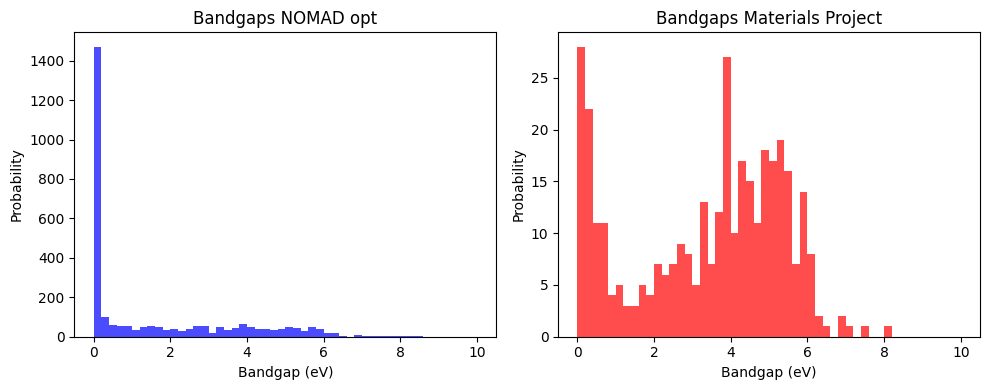

In [36]:
mp_bandgaps = [doc.band_gap for doc in resultsMP2]
print(mp_bandgaps[:10])
print(df2.head())
print(f'NOMAD found {len(df2)} entries.')
print(f'Materials Project found {len(mp_bandgaps)} entries.')

# 1. Create a figure with histograms
import matplotlib.pyplot as plt
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df2['bandgap_eV'], bins=50, alpha=0.7, color='blue', range=[1e-10, 10])
ax1.set_title('Bandgaps NOMAD opt')
ax1.set_xlabel('Bandgap (eV)')
ax1.set_ylabel('Probability')

ax2.hist(mp_bandgaps, bins=50, alpha=0.7, color='red', range=[1e-10, 10])
ax2.set_title('Bandgaps Materials Project')
ax2.set_xlabel('Bandgap (eV)')
ax2.set_ylabel('Probability')

plt.tight_layout()
plt.savefig('bg_NOMADxMP.png', dpi=300, bbox_inches='tight')

**Stability check in NOMAD**
NOMAD is an uncurated repository of raw code calculations rather than a unified thermodynamic database. Because it stores millions of independent simulations uploaded by different users using varied parameters (DFT functionals, cutoffs, k-points), NOMAD does not provide a single, universal is_stable flag or a pre-calculated energy_above_hull like the Materials Project does. To check if a compound is stable using NOMAD, you must calculate its thermodynamic stability yourself by applying the Convex Hull method to its formation energy.
[1] (https://matsci.org/t/api-search-engine-for-specific-compounds-in-nomad/58088)
[2] (https://www.sciencedirect.com/org/science/article/pii/S2635098X24001219)
[3] (https://www.nature.com/articles/s41524-020-00362-y)

**Comparison Materials Project vs. NOMAD**
1. Data availability and coverage     
BeO entries found:    MP: 459  /  NOMAD: 5266     
Total data volume:  MP > 150 k / NOMAD > 15 M
- Materials Project: Provides excellent high-fidelity coverage for ordered crystal structures, batteries, elastic tensors, and basic band structures. It is structurally bounded because it contains calculations generated intentionally by the MP team using unified software settings.
- NOMAD: Massive, unmatched scale. It captures not just the relaxed ground-state crystals, but millions of mid-run trajectory points, molecular dynamics (MD) steps, excited states, and diverse calculation frameworks (DFT, GW, force fields) that are completely absent from the Materials Project.

2. Ease of Access and API Usability     
- Materials Project: Highly accessible. The native python library mp_api.client allows users to search intuitively using human-readable parameter constraints (e.g., band_gap=(0.5, 3.0)).
- NOMAD: Steeper learning curve. The HTTP REST API handles queries via highly granular query language blocks.

3. Data Format and Standardization     
Primary Units:  
MP: eV, Å³  (standard data science formats)
NOMAD: J, m³ (Strict SI units).
- Materials Project: Standardizes data schemas completely. All structures use native Python structures easily translated into Pymatgen objects or flat DataFrames.
- NOMAD: Standardizes the metadata layer via the NOMAD Metainfo system to translate 40+ diverse simulation codes (VASP, Quantum ESPRESSO, Gaussian, CASTEP) into a shared naming convention. However, parsing it requires managing array wrappers and standard SI units (like Joules instead of the universally preferred eV).

4. Metadata Quality     
- Materials Project: Highly reliable metadata because calculation variables (functionals, pseudopotentials, k-points) are strictly uniform across entries, making properties directly comparable.
- NOMAD: Incredibly rich and exhaustive metadata, but comparing the quality of two different entries requires manually inspecting their source metadata.

5. Use Cases for Each Repository     
- Materials Project: Ideal for rapid material screening, discovery of stable phases, filtering candidate materials for specific applications (like thermoelectrics or batteries), and teaching materials informatics.
- NOMAD: Ideal for data mining, training machine learning interatomic potentials, harvesting molecular dynamics trajectories, studying rare or unrelaxed configurations, and verifying the reproducibility of specific computational physics codes.


**Feature Comparison Matrix**

**Philosophy     
-Materials Project (MP) Curated, uniform database.  
-NOMAD High-throughput, comprehensive open archive.

**Data Source     
-Materials Project (MP) Centralized high-throughput DFT runs (primarily VASP).  
-NOMAD Community crowdsourced uploads from over 40+ simulation codes.

**API Architecture     
-Materials Project (MP) mp-api wrapper client with straightforward endpoints.  
-NOMAD Layered raw REST API with highly-nested JSON schemas.

**Thermodynamic Data     
-Materials Project (MP) Pre-computed phase diagrams and energy_above_hull flags.  
-NOMAD Raw total energies; user must handle phase diagram construction.

In [37]:
#Task 3.5: Data Integration Challenge

#take data from JARVIS-DFT from JARVIS-DB
#This code from https://colab.research.google.com/github/knc6/jarvis-tools-notebooks/blob/master/jarvis-tools-notebooks/Analyzing_data_in_the_JARVIS_DFT_dataset.ipynb#scrollTo=VU7_uav2wAVN
!pip install jarvis-tools
from jarvis.db.figshare import data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 32.3 MB/s eta 0:00:00


In [38]:
dft_3d = data('dft_3d')
dft_2d = data('dft_2d')

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699


100%|██████████| 48.4M/48.4M [00:03<00:00, 13.7MiB/s]


Loading the zipfile...
Loading completed.
Obtaining 2D dataset 1.1k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815705


100%|██████████| 8.39M/8.39M [00:00<00:00, 9.66MiB/s]


Loading the zipfile...
Loading completed.


In the NIST-JARVIS infrastructure, the 2D dataset (dft_2d) referes to Monolayers, bilayers, and ultra-thin low-dimensional sheets, whereas the 3D dataset (dft_3d) refers to Bulk crystalline solids (metals, ceramics, minerals).

Repositories: 3D is large (>80k structures), 2D is focused (> 1,1k structures)

Applications: The 3D dataset acts as a wide net for discovery in industrial fields like thermoelectrics, mechanics, and photovoltaics. The 2D dataset specifically aims at flexible electronics, Si-replacement channels, monolayer superconductors, and heterojunction engineering.

Simulation setup:
- 3D: Standard periodic boundary conditions in all 3 spatial directions. Focuses on bulk 3D tensors (e.g., full elastic constants, bulk/shear modulus).
- 2D: Large vacuum padding along one axis (usually ~20 Å) to prevent layer-to-layer interactions. Focuses heavily on exfoliation energy (the energy needed to peel the sheet away from its bulk parent).

Computational cost: 2D is highly demaing.

In [39]:
import numpy as np
# data-size
print (len(dft_3d),len(dft_2d))

# let's make a pandas dataframe from the figshare json file
df=pd.DataFrame(dft_3d)
# Keys in the json file
print (df.columns, len(df.columns))
#Lets count number of entries for each available property
for i in df.columns.values:
  val=df[i].replace('na',np.nan).dropna().values
  print(i,len(val))


93902 1103
Index(['jid', 'spg_number', 'spg_symbol', 'formula',
       'formation_energy_peratom', 'func', 'optb88vdw_bandgap', 'atoms',
       'slme', 'magmom_oszicar', 'spillage', 'elastic_tensor',
       'effective_masses_300K', 'kpoint_length_unit', 'maxdiff_mesh',
       'maxdiff_bz', 'encut', 'optb88vdw_total_energy', 'epsx', 'epsy', 'epsz',
       'mepsx', 'mepsy', 'mepsz', 'modes', 'magmom_outcar', 'max_efg',
       'avg_elec_mass', 'avg_hole_mass', 'icsd', 'dfpt_piezo_max_eij',
       'dfpt_piezo_max_dij', 'dfpt_piezo_max_dielectric',
       'dfpt_piezo_max_dielectric_electronic',
       'dfpt_piezo_max_dielectric_ionic', 'max_ir_mode', 'min_ir_mode',
       'n-Seebeck', 'p-Seebeck', 'n-powerfact', 'p-powerfact', 'ncond',
       'pcond', 'nkappa', 'pkappa', 'ehull', 'Tc_supercon', 'dimensionality',
       'efg', 'xml_data_link', 'typ', 'exfoliation_energy', 'spg', 'crys',
       'density', 'poisson', 'raw_files', 'nat', 'bulk_modulus_kv',
       'shear_modulus_gv', 'mbj_bandga

/tmp/ipykernel_2660/760042643.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  val=df[i].replace('na',np.nan).dropna().values


elastic_tensor 34502
effective_masses_300K 93902
kpoint_length_unit 93558
maxdiff_mesh 5861
maxdiff_bz 5861
encut 93557
optb88vdw_total_energy 93902
epsx 60354
epsy 60354
epsz 60354
mepsx 19834
mepsy 19834
mepsz 19834
modes 13910
magmom_outcar 92170
max_efg 11871
avg_elec_mass 17645
avg_hole_mass 17645
icsd 93902
dfpt_piezo_max_eij 4799
dfpt_piezo_max_dij 3347
dfpt_piezo_max_dielectric 4706
dfpt_piezo_max_dielectric_electronic 4809
dfpt_piezo_max_dielectric_ionic 4809
max_ir_mode 4805
min_ir_mode 4809
n-Seebeck 23218
p-Seebeck 23218
n-powerfact 23218
p-powerfact 23218
ncond 23218
pcond 23218
nkappa 23218
pkappa 23218
ehull 93902
Tc_supercon 1058
dimensionality 93383
efg 93902
xml_data_link 93902
typ 93902
exfoliation_energy 813
spg 93902
crys 93902
density 93902
poisson 32205
raw_files 93902
nat 93902
bulk_modulus_kv 32433
shear_modulus_gv 32433
mbj_bandgap 21559
hse_gap 56
reference 93902
search 93902


In [40]:
#Filter dataset based on a set of elements
from jarvis.core.atoms import Atoms
def has_elements(atoms_dict = {}, my_element = ['Be','O']):
#this function will list oxides containing only Be and O, no multicompound
    atoms = Atoms.from_dict(atoms_dict)
    elements = atoms.elements
    if set(my_element)==set(elements):
        return True
    else:
        return np.nan

df['el'] = df['atoms'].apply(lambda x: has_elements(atoms_dict = x, my_element = ['Be','O']))
df1 = df.dropna()
print ('#entries:',len(df1))
df1.head()

#entries: 8


,jid,spg_number,spg_symbol,formula,formation_energy_peratom,func,optb88vdw_bandgap,atoms,slme,magmom_oszicar,...,poisson,raw_files,nat,bulk_modulus_kv,shear_modulus_gv,mbj_bandgap,hse_gap,reference,search,el
21788,JVASP-22522,216,F-43m,BeO,-3.02511,OptB88vdW,7.293,"{'lattice_mat': [[2.342675361606875, -0.0, 1.3...",0.0,na,...,0.21,"[FD-ELAST,JVASP-22522.zip,https://ndownloader....",2,215.73,168.68,9.23,na,mp-1778,-Be-O,True
28207,JVASP-58368,136,P4_2/mnm,BeO,-3.01401,OptB88vdW,7.605,"{'lattice_mat': [[4.641911925945633, 0.0, 0.0]...",0.0,0.0,...,0.23,"[FD-ELAST,JVASP-58368.zip,https://ndownloader....",8,205.8,134.14,9.009,na,mp-7599,-Be-O,True
35009,JVASP-20778,186,P6_3mc,BeO,-3.03116,OptB88vdW,8.040,"{'lattice_mat': [[1.356277040348664, -2.349141...",na,0.0,...,0.21,"[FD-ELAST,JVASP-20778.zip,https://ndownloader....",4,215.74,159.29,na,na,mp-2542,-Be-O,True
46042,JVASP-57665,225,Fm-3m,BeO,-2.53707,OptB88vdW,8.761,"{'lattice_mat': [[2.229670615977821, -3.360367...",0.0,0.0,...,0.24,"[FD-ELAST,JVASP-57665.zip,https://ndownloader....",2,252.13,209.54,9.687,na,mp-1794,-Be-O,True
81554,JVASP-183648,123,P4/mmm,Be3O2,-1.74786,OptB88vdW,0.000,"{'lattice_mat': [[2.4237905490973497, -0.0, -0...",na,0.0,...,0.29,[],5,114.93,66.24,na,na,JQE-243467,-Be-O,True


In [41]:
#Filter database for all Be containing oxides
import numpy as np
from jarvis.core.atoms import Atoms

def is_Be_oxide(atoms_dict={}, target_elements=['Be', 'O']):
    """
    Returns True if the material contains at least Be and O,
    allowing for multicompound structures (3 or more elements).
    """
    atoms = Atoms.from_dict(atoms_dict)
    elements = set(atoms.elements)

    # Check if BOTH Be and O are present, AND there is at least one other element
    if set(target_elements).issubset(elements): # and len(elements) >= 3:
        return True
    else:
        return np.nan

# Apply the updated filter function
df['el'] = df['atoms'].apply(lambda x: is_Be_oxide(atoms_dict=x, target_elements=['Be', 'O']))
dfJarvis = df.dropna()
#print(dfJarvis.head())
print('# Multicompound entries found:', len(dfJarvis))

dfJ = dfJarvis[["formula", "optb88vdw_bandgap"]].rename(columns={"optb88vdw_bandgap": "bandgapJARVIS"})
print(dfJ.head())

# Save the complete DataFrame to a clean JSON  file
dfJarvis.to_json("JARVIS BeO df1.json", orient="records", indent=4)
print("-> Successfully saved the DataFrame to 'JARVIS BeO df1.json'")
'''
# We can store the screened materials in a new json file
from jarvis.db.jsonutils import dumpjson
dumpjson(data = df1.values.tolist(), filename='JARVIS_BeO.json')
'''

# Multicompound entries found: 191
                formula  bandgapJARVIS
536            CaBePO4F          6.185
681            Ta2Be2O5          0.000
1762  Li2Ca3Be3Si3O12F2          5.922
1906        RbNa5Be8O11          3.928
2145        LiBeH8CNOF4          5.947
-> Successfully saved the DataFrame to 'JARVIS BeO df1.json'


"\n# We can store the screened materials in a new json file\nfrom jarvis.db.jsonutils import dumpjson\ndumpjson(data = df1.values.tolist(), filename='JARVIS_BeO.json')\n"

/tmp/ipykernel_2660/3786252767.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  val=np.array(df['mbj_bandgap'].replace('na',np.nan).dropna().values,dtype='float')


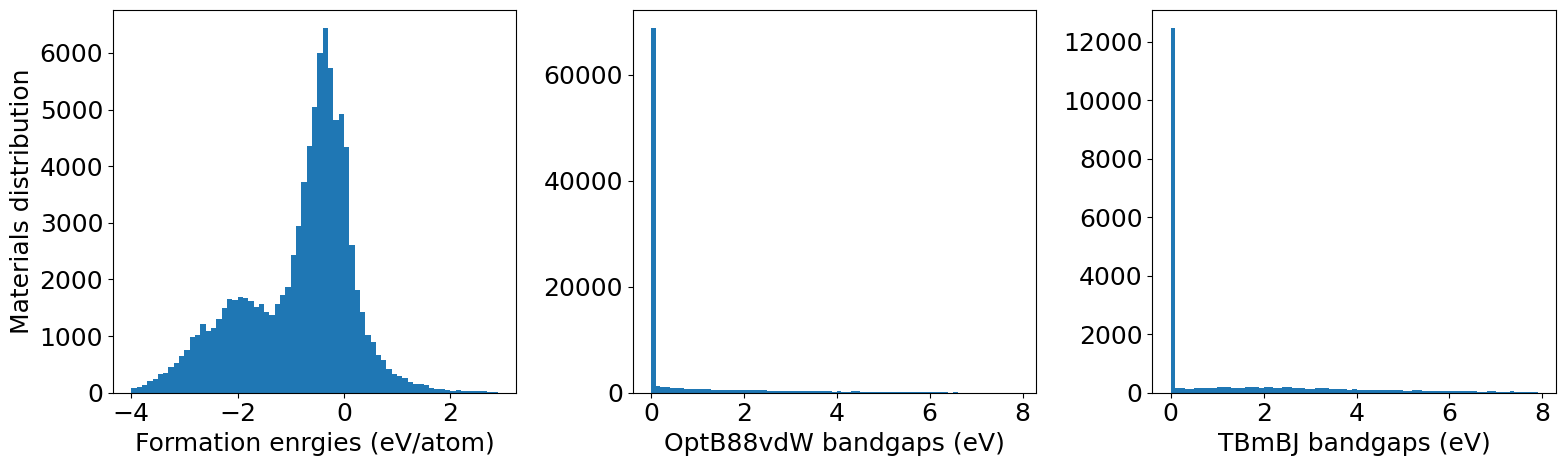

In [42]:
# Now let's make a histogram for some of the material-properties in the dataset
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

the_grid = GridSpec(1, 3)
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(16,5))

plt.subplot(the_grid[0, 0])
val=np.array(df['formation_energy_peratom'].replace('na',np.nan).dropna().values,dtype='float')

plt.hist(val,bins=np.arange(-4,3,.1))
plt.xlabel('Formation enrgies (eV/atom)')
plt.ylabel('Materials distribution')

plt.subplot(the_grid[0, 1])
val=np.array(df['optb88vdw_bandgap'].replace('na',np.nan).dropna().values,dtype='float')
plt.hist(val,bins=np.arange(0,8,.1))
plt.xlabel('OptB88vdW bandgaps (eV)')
#plt.ylabel('Materials distribution')

plt.subplot(the_grid[0, 2])
val=np.array(df['mbj_bandgap'].replace('na',np.nan).dropna().values,dtype='float')
plt.hist(val,bins=np.arange(0,8,.1))
plt.xlabel('TBmBJ bandgaps (eV)')
#plt.ylabel('Materials distribution')

plt.tight_layout()


/tmp/ipykernel_2660/2736879303.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2=df[['optb88vdw_bandgap','mbj_bandgap']].replace('na',np.nan).dropna()


Mats. with both OptB88vdW bandgaps 93902
Mats. with both TBmBJ abd OptB88vdW bandgaps 21559


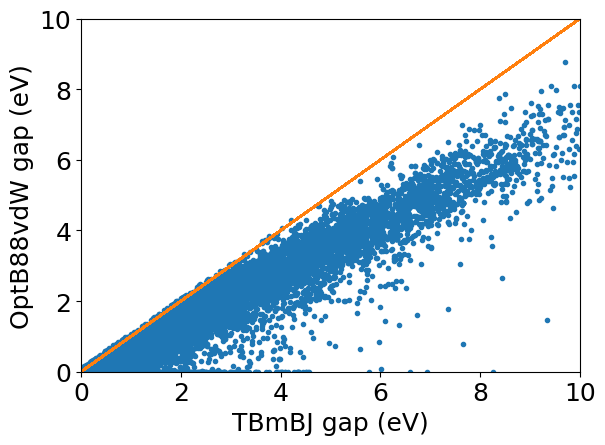

In [43]:
# Let's compare OptB88vdW and TBmBJ bandgaps
df2=df[['optb88vdw_bandgap','mbj_bandgap']].replace('na',np.nan).dropna()
plt.plot(df2['mbj_bandgap'], df2['optb88vdw_bandgap'],'.')
plt.plot(df2['mbj_bandgap'], df2['mbj_bandgap'])
plt.xlim([0,10])
plt.ylim([0,10])
plt.xlabel('TBmBJ gap (eV)')
plt.ylabel('OptB88vdW gap (eV)')
plt.tight_layout()
print ('Mats. with both OptB88vdW bandgaps', len(df['optb88vdw_bandgap']))
print ('Mats. with both TBmBJ abd OptB88vdW bandgaps', len(df2['mbj_bandgap']))

In the NIST-JARVIS database, the Tran-Blaha modified Becke-Johnson (TBmBJ) meta-GGA potential systematically predicts more accurate electronic bandgaps than the van der Waals density functional OptB88vdW (OPT), effectively correcting the standard underestimation of bandgaps seen in conventional generalized gradient approximation (GGA) methods.

Key Differences and Comparison
Methodology Level: OptB88vdW is a non-local van der Waals functional used primarily for reliable geometry optimization and general property calculations across tens of thousands of materials in JARVIS-DFT. TBmBJ is a semi-local meta-GGA potential applied selectively to compute superior bandgaps and dielectric functions.

Computational Cost: OptB88vdW calculations are efficient and serve as the baseline for structural relaxation. TBmBJ calculations are more expensive than standard GGA but remain significantly cheaper than hybrid functionals (PBE0, HSE06) or GW.

Database Coverage: OptB88vdW covers a much larger portion of the database (over 77,000 3D materials), whereas TBmBJ data is available for a focused subset (over 18,000 materials) optimized for optoelectronic analysis.

Further Exploration
-Read the benchmark study on Scientific Data. (https://pmc.ncbi.nlm.nih.gov/articles/PMC12927023/)
-Access raw data files via NIST. (https://www.nature.com/articles/sdata201882)
-Review alternative model tests on PubMed Central. (https://www.nist.gov/publications/computational-screening-high-performance-optoelectronic-materials-using-optb88vdw-and)



In [44]:
#Material-screening example
#Let's find materials which has Bi element, has spin-orbit spillage >= 0.5, have OptB88vdW bandgaps > 0.1, energy above convex hull < 0.1 eV/atom , have SLME >5 %
df3 = df[['optb88vdw_bandgap','spillage', 'ehull', 'slme', 'atoms', 'jid']].replace('na',np.nan).dropna()
from jarvis.core.atoms import Atoms
def has_element(atoms_dict = {}, my_element = 'Bi'):
    atoms = Atoms.from_dict(atoms_dict)
    elements = atoms.elements
    if my_element in elements:
        return True
    else:
        return np.nan

df3['el'] = df3['atoms'].apply(lambda x: has_element(atoms_dict = x, my_element = 'Bi'))
df3['formula'] = df3['atoms'].apply(lambda x: Atoms.from_dict(x).composition.reduced_formula)

df4 = df3.dropna()
df4[(df4['optb88vdw_bandgap'] >= .1) & (df4['spillage'] >=.5 ) & (df4['ehull'] <=.1 ) & (df4['slme'] >=5 )  ]
print(f" df4 has {len(df4)} entries")
print(df4.head())


 df4 has 123 entries
       optb88vdw_bandgap  spillage   ehull   slme  \
3518               0.011     3.451  0.5330   5.84   
4686               0.504     2.022  0.2590  31.11   
11718              0.456     2.040  0.4423  25.50   
12442              1.098     0.171  0.0000  25.40   
13837              0.948     0.182  0.0029  30.34   

                                                   atoms          jid    el  \
3518   {'lattice_mat': [[-4.436076177399659, 0.014849...   JVASP-5260  True   
4686   {'lattice_mat': [[0.0, 3.485394766378691, 3.48...  JVASP-22724  True   
11718  {'lattice_mat': [[4.42505744378599, 0.02032676...   JVASP-2023  True   
12442  {'lattice_mat': [[5.359639026082461, 0.0, 0.0]...  JVASP-22715  True   
13837  {'lattice_mat': [[6.383233820540264, 0.0, 0.0]...   JVASP-3819  True   

       formula  
3518    Bi2TeI  
4686   NaLi2Bi  
11718  TlBiTe2  
12442    KCaBi  
13837   K2AgBi  


/tmp/ipykernel_2660/1397523875.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3 = df[['optb88vdw_bandgap','spillage', 'ehull', 'slme', 'atoms', 'jid']].replace('na',np.nan).dropna()


In [45]:
#Find all cubic materials
df5 = df[['optb88vdw_bandgap','atoms', 'jid','crys']].replace('na',np.nan).dropna()

df5['formula'] = df5['atoms'].apply(lambda x: Atoms.from_dict(x).composition.reduced_formula)

print(f" df5 has {len(df5)} entries")
print(df5.head())

print(f" df5[df5['crys']=='cubic'] has {len(df5[df5['crys']=='cubic'])} entries")
print(df5[df5['crys']=='cubic'].head())

# We can store the screened materials in a new json file
# Note that the primitive cell can have non-equal lattice-constants but not the conventional cell
from jarvis.db.jsonutils import dumpjson
dumpjson(data = df[df['crys']=='cubic']['atoms'].values.tolist(), filename='JARVIS_all_cubic.json')

 df5 has 93902 entries
   optb88vdw_bandgap                                              atoms  \
0              0.000  {'lattice_mat': [[3.566933224304235, 0.0, -0.0...   
1              0.000  {'lattice_mat': [[4.089078911208881, 0.0, 0.0]...   
2              0.000  {'lattice_mat': [[-1.833590720595598, 1.833590...   
3              0.472  {'lattice_mat': [[7.2963518353359165, 0.0, 0.0...   
4              0.000  {'lattice_mat': [[1.6777483798834445, -2.90594...   

           jid        crys   formula  
0  JVASP-90856  tetragonal  TiCuSiAs  
1  JVASP-86097       cubic      DyB6  
2  JVASP-64906  tetragonal   Be2OsRu  
3  JVASP-98225  monoclinic       KBi  
4     JVASP-10    trigonal      VSe2  
 df5[df5['crys']=='cubic'] has 22697 entries
    optb88vdw_bandgap                                              atoms  \
1                 0.0  {'lattice_mat': [[4.089078911208881, 0.0, 0.0]...   
6                 0.0  {'lattice_mat': [[0.0, 5.1858714074842, 5.1858...   
7                 0

In [46]:
#Find all Be oxides in Materials Project
with MPRester(LiliaCN_API) as mpr:
  summary_subrester = mpr.materials.summary  # Sub-Resters are usually attributes of MPRester

  resultsMP_BeO = summary_subrester.search(elements=["Be","O"]) # Be and O are required, but other elements also allowed

  print(f"The number of returned materials is: {len(resultsMP_BeO)}")



Retrieving SummaryDoc documents:   0%|          | 0/459 [00:00<?, ?it/s]

The number of returned materials is: 459


In [47]:
#Create DataFrame using formula in the same format as JARVIS and NOMAD

'''for i in range(10):
  print(str(resultsMP_BeO[i].composition_reduced))
  print(resultsMP_BeO[i].formula_pretty)'''

def compostition_reduced2formula(composition_reduced):
  cr=str(composition_reduced)
  cr=cr.replace(' ','')
  cr=cr.replace('1','')
  return cr
'''
form0 = compostition_reduced2formula(resultsMP_BeO[1].composition_reduced)
print('form0',form0)
'''
mp_cr = [doc.composition_reduced for doc in resultsMP_BeO]
#print(mp_cr[:10])
mp_form = [compostition_reduced2formula(doc.composition_reduced) for doc in resultsMP_BeO]
#print(mp_form[:10])
mp_bandgaps = [doc.band_gap for doc in resultsMP_BeO]

dfMP = pd.DataFrame(list(zip(mp_form, mp_bandgaps )), columns = ['formula', 'bandgap'])
print(dfMP.head(10))
print(dfMP.shape)


     formula  bandgap
0       BeO2   0.0000
1    BeFe2O4   1.7691
2    Mn2BeO4   0.0000
3     BeCrO4   2.4299
4    BeFe2O4   1.7507
5    BeCo2O4   2.1275
6  Li3BePCO7   5.3704
7   BeBi2O20   0.0000
8     BeCrO4   2.2720
9   K3BePCO7   4.0032
(459, 2)


In [48]:
#Get the complete list of 18k Be containing oxide entries from NOMAD v1
import requests
import json
import pandas as pd
import time

#Access data using NOMAD API access
# NOMAD API base URL  NEW
BASE_URL = "https://nomad-lab.eu/prod/v1/api/v1"

# Headers for requests (only Accept header for GET requests)
headers = {
    'Accept': 'application/json',
    'Content-Type': 'application/json'
}

# Define the query payload
payload = {
    "query": {
        "results.material.elements": {"all": ["Be", "O"]}
    },
    "pagination": {
        "page_size": 1000  # Fetching in batches of 1000 -> a server-friendly batch size
    }
}

flattened_rows = []

print("Querying NOMAD API v1...")

while True:
    response = requests.post(f"{BASE_URL}/entries/query", headers=headers, json=payload)
    response.raise_for_status()
    data = response.json()

    entries = data.get("data", [])
    if not entries:
        break

    # Parse entries into the list right away
    for entry in entries:
        entry_id = entry.get('entry_id', 'N/A')  #<class 'str'>
        results = entry.get("results", {})
        material = results.get("material", {})
        properties = results.get("properties", {})

        # Safely extract electronic band gap list
        electro = properties.get("electronic", {})
        band_gap = electro.get("band_gap", [])
        # Get the value of the first band gap if available
        bg_valueJ = band_gap[0]['value'] if band_gap else None
        # Automatically convert to eV if a value exists
        bg_eV = bg_valueJ / 1.602176634e-19 if bg_valueJ is not None else None

        row = {
        "entry_id": entry_id,
        #"formula_pretty": material.get("formula_pretty", 'N/A'),
        "formula": material.get("chemical_formula_reduced", 'N/A'),
        "elements": material.get("elements", 'N/A'),
        "bandgap": bg_eV
            }
        #print(row)

        flattened_rows.append(row)

    # Move to the next page token
    next_token = data.get("pagination", {}).get("next_page_after_value", None)
    if next_token:
        payload["pagination"]["page_after_value"] = next_token
        time.sleep(0.1)  # Minimal server delay
    else:
        break

# 📊 1. Create the complete DataFrame
dfNMD = pd.DataFrame(flattened_rows)
print(f"\nAll data loaded into DataFrame. Shape: {dfNMD.shape}")
print(dfNMD.head())

# 💾 2. Create the JSON file directly from the DataFrame!
json_filename = "NOMAD_BeO_data.json"
dfNMD.to_json(json_filename, orient="records", indent=4)
print(f"Successfully generated '{json_filename}' from the DataFrame.")


Querying NOMAD API v1...

All data loaded into DataFrame. Shape: (18189, 4)
                       entry_id    formula         elements  bandgap
0  --AtyFeolaw2Gp1PR_CYa9P8rhuQ   AlBeO4Sc  [Al, Be, O, Sc]   3.8875
1  --DQzTzUbN9PJcKHRbj3OCMJguCw   Ba2BeO6V   [Ba, Be, O, V]   0.0159
2  --L8wRH6yEQHulanDqlLcEc3vUde  BeNa2O4Pd  [Be, Na, O, Pd]   0.4343
3  --OCV3qTN7kHC_hLOxyPSGOPj7LC        BeO          [Be, O]      NaN
4  --ZkSAXor2VF9pZteiLVaSSm4vaQ  BeCd2GaO4  [Be, Cd, Ga, O]   0.0470
Successfully generated 'NOMAD_BeO_data.json' from the DataFrame.


In [49]:
#  print(resultsMP[:1]['formula_pretty'])
#for i in range(10): #(len(results)):
#  print(resultsMP[i].formula_pretty)

# Direct one-liner
for r in resultsMP_BeO[:10]: print(r.formula_pretty)

BeO2
Be(FeO2)2
Mn2BeO4
BeCrO4
Be(FeO2)2
Be(CoO2)2
Li3BePCO7
Be(Bi3O5)4
BeCrO4
K3BePCO7


In [50]:
#Compare number of entries found
print(f"The number of Be containing oxides from MP is {len(dfMP)}.")
print(f"The number of Be containing oxides from NOMAD is {len(dfNMD)}.")
print(f"The number of Be containing oxides from JARVIS is {len(dfJ)}.")

print('MP')
print(dfMP.head())
print('NOMAD')
print(dfNMD.head())
#dfNMD = dfNMD[["formula", "bandgap"]]
#print(dfNMD.head())
print('JARVIS')
print(dfJ.head() )

The number of Be containing oxides from MP is 459.
The number of Be containing oxides from NOMAD is 18189.
The number of Be containing oxides from JARVIS is 191.
MP
   formula  bandgap
0     BeO2   0.0000
1  BeFe2O4   1.7691
2  Mn2BeO4   0.0000
3   BeCrO4   2.4299
4  BeFe2O4   1.7507
NOMAD
                       entry_id    formula         elements  bandgap
0  --AtyFeolaw2Gp1PR_CYa9P8rhuQ   AlBeO4Sc  [Al, Be, O, Sc]   3.8875
1  --DQzTzUbN9PJcKHRbj3OCMJguCw   Ba2BeO6V   [Ba, Be, O, V]   0.0159
2  --L8wRH6yEQHulanDqlLcEc3vUde  BeNa2O4Pd  [Be, Na, O, Pd]   0.4343
3  --OCV3qTN7kHC_hLOxyPSGOPj7LC        BeO          [Be, O]      NaN
4  --ZkSAXor2VF9pZteiLVaSSm4vaQ  BeCd2GaO4  [Be, Cd, Ga, O]   0.0470
JARVIS
                formula  bandgapJARVIS
536            CaBePO4F          6.185
681            Ta2Be2O5          0.000
1762  Li2Ca3Be3Si3O12F2          5.922
1906        RbNa5Be8O11          3.928
2145        LiBeH8CNOF4          5.947


MP is showing the pretty formula format, e.g. Be(FeO2)2, whereas NOMAD and JARVIS use the simple one, e.g. BeFe2O4. You have to harmonize this before merging.

In [51]:
df_MP = dfMP.rename(columns={'bandgap':'bg_MP'})
dfNMD = dfNMD.rename(columns={'bandgap':'bg_NMD'})
df_NMD = dfNMD[["formula", "bg_NMD"]]
#df_J = dfJ[["formula", "bandgapJARVIS"]]
# Reset the numbers so they start from 0 and go up sequentially
df_J = dfJ.reset_index(drop=True)


print('MP', df_MP.shape)
print(df_MP.head())
print('NOMAD', df_NMD.shape)
print(df_NMD.head())
print('JARVIS', df_J.shape)
print(df_J.head() )

print("Duplicate formulas in MP:", dfMP.duplicated(subset=['formula']).sum())
print("Duplicate formulas in NOMAD:", dfNMD.duplicated(subset=['formula']).sum())
print("Duplicate formulas in JARVIS:", df_J.duplicated(subset=['formula']).sum())



MP (459, 2)
   formula   bg_MP
0     BeO2  0.0000
1  BeFe2O4  1.7691
2  Mn2BeO4  0.0000
3   BeCrO4  2.4299
4  BeFe2O4  1.7507
NOMAD (18189, 2)
     formula  bg_NMD
0   AlBeO4Sc  3.8875
1   Ba2BeO6V  0.0159
2  BeNa2O4Pd  0.4343
3        BeO     NaN
4  BeCd2GaO4  0.0470
JARVIS (191, 2)
             formula  bandgapJARVIS
0           CaBePO4F          6.185
1           Ta2Be2O5          0.000
2  Li2Ca3Be3Si3O12F2          5.922
3        RbNa5Be8O11          3.928
4        LiBeH8CNOF4          5.947
Duplicate formulas in MP: 80
Duplicate formulas in NOMAD: 15595
Duplicate formulas in JARVIS: 34


If you merge directly the dataframes, a dramatic increase in rows happens because you are performing a many-to-many merge on a key (most likely the chemical formula) that contains duplicate entries in each dataset.

In materials databases like Materials Project (MP), NOMAD, and JARVIS, a single chemical formula can have multiple different crystal structures (polymorphs). When pandas merges on a key with duplicates, it creates a Cartesian product (every possible combination) for those matches.

**How the Math Works (The Cartesian Product)**

If a specific formula (e.g., TiO2) appears multiple times in your datasets:MP has it 4 times (4 different structures) and NOMAD has it 20 times -> When you merge them, pandas matches every single MP structure with every single NOMAD structure for that formula. This results in 4 x 20 = 80 rows for just that one formula. Multiply this effect across hundreds of materials, and your row count explodes.

In [84]:
#clean data to make it merge correctly

#MP: Check for and remove NaN values
#df2 = df.copy()
print('MP after before NAN', df_MP.shape)
print(df_MP.head())
bool_nans_bg = df_MP['bg_MP'].isnull()

# Drop the rows of the DataFrame which contain bg NaNs
dfMP1 = df_MP.drop(df_MP.loc[bool_nans_bg].index, axis=0)
print('MP after drop NAN', dfMP1.shape)
print(dfMP1.head())

# Returns True if there is at least one negative value anywhere in the DF
print('Negative values', (dfMP1.select_dtypes(include='number') < 0).any().any())

# Drop the rows of the DataFrame which contain bg=0
bool_not0bg = dfMP1['bg_MP']>0
#print(bool_not0bg.head())
bool_0bg = bool_not0bg.apply(lambda x: not x)
#print(bool_0bg.head())
dfMP2 = dfMP1.drop(dfMP1.loc[bool_0bg].index, axis=0)
print('MP after drop 0s', dfMP2.shape)
print(dfMP2.head())

# take the average value of all duplicate formulas and replace the duplicate
# formulas with the average bandgap value.
dfMP3 = dfMP2.groupby('formula', as_index=False)['bg_MP'].mean()
print('MP after averaging duplicates', dfMP3.shape)
print(dfMP3.head())


MP after before NAN (459, 2)
   formula   bg_MP
0     BeO2  0.0000
1  BeFe2O4  1.7691
2  Mn2BeO4  0.0000
3   BeCrO4  2.4299
4  BeFe2O4  1.7507
MP after drop NAN (459, 2)
   formula   bg_MP
0     BeO2  0.0000
1  BeFe2O4  1.7691
2  Mn2BeO4  0.0000
3   BeCrO4  2.4299
4  BeFe2O4  1.7507
Negative values False
MP after drop 0s (357, 2)
     formula   bg_MP
1    BeFe2O4  1.7691
3     BeCrO4  2.4299
4    BeFe2O4  1.7507
5    BeCo2O4  2.1275
6  Li3BePCO7  5.3704
MP after averaging duplicates (298, 2)
       formula     bg_MP
0   Ba2BeSO4F4  3.825800
1     Ba2UBeO6  1.739900
2  Ba3Be2B5HO3  3.613924
3    BaBe2B2O4  0.230800
4    BaBe2B2O6  5.365450


In [56]:
#NOMAD: Check for and remove NaN values
print('NOMAD after before NAN', df_NMD.shape)
print(df_NMD.head())
bool_nans_bgNMD = df_NMD['bg_NMD'].isnull()

# Drop the rows of the DataFrame which contain bg NaNs
dfNMD1 = df_NMD.drop(df_NMD.loc[bool_nans_bgNMD].index, axis=0)
print('NMD after drop NAN', dfNMD1.shape)
print(dfNMD1.head())

# Drop the rows of the DataFrame which contain bg=0
bool_not0bg = dfNMD1['bg_NMD']>0
print(bool_not0bg.shape)
#print(bool_not0bg.head())
bool_0bg = bool_not0bg.apply(lambda x: not x)
#print(bool_0bg.head())
dfNMD2 = dfNMD1.drop(dfNMD1.loc[bool_0bg].index, axis=0)
print('NMD after drop 0s', dfNMD2.shape)
print(dfNMD2.head())

# take the average value of all duplicate formulas and replace the duplicate
# formulas with the average bandgap value.
dfNMD3 = dfNMD2.groupby('formula', as_index=False)['bg_NMD'].mean()
print('NMD after averaging duplicates', dfNMD3.shape)
print(dfNMD3.head())

NOMAD after before NAN (18189, 2)
     formula  bg_NMD
0   AlBeO4Sc  3.8875
1   Ba2BeO6V  0.0159
2  BeNa2O4Pd  0.4343
3        BeO     NaN
4  BeCd2GaO4  0.0470
NMD after drop NAN (9523, 2)
     formula  bg_NMD
0   AlBeO4Sc  3.8875
1   Ba2BeO6V  0.0159
2  BeNa2O4Pd  0.4343
4  BeCd2GaO4  0.0470
5    BeCaO2P  0.0104
(9523,)
NMD after drop 0s (5163, 2)
     formula  bg_NMD
0   AlBeO4Sc  3.8875
1   Ba2BeO6V  0.0159
2  BeNa2O4Pd  0.4343
4  BeCd2GaO4  0.0470
5    BeCaO2P  0.0104
NMD after averaging duplicates (1693, 2)
      formula    bg_NMD
0   Ac2AsBeO6  1.996800
1  Ac2Be2CaO6  3.313133
2  Ac2Be2CdO6  2.818500
3  Ac2Be2CoO6  1.987075
4  Ac2Be2HoO6  0.063900


In [57]:
#JARVIS: Check for and remove NaN values
print('JARVIS after before NAN', df_J.shape)
print(df_J.head())
bool_nans_bgJ = df_J['bandgapJARVIS'].isnull()
# Drop the rows of the DataFrame which contain bg NaNs
dfJ1 = df_J.drop(df_J.loc[bool_nans_bgJ].index, axis=0)
print('JARVIS after drop NAN', dfJ1.shape)
print(dfJ1.head())

# Drop the rows of the DataFrame which contain bg=0
bool_not0bg = dfJ1['bandgapJARVIS']>0
print(bool_not0bg.shape)
#print(bool_not0bg.head())
bool_0bg = bool_not0bg.apply(lambda x: not x)
#print(bool_0bg.head())
dfJ2 = dfJ1.drop(dfJ1.loc[bool_0bg].index, axis=0)
print('JARVIS after drop 0s', dfJ2.shape)
print(dfJ2.head())

# take the average value of all duplicate formulas and replace the duplicate
# formulas with the average bandgap value.
dfJ3 = dfJ2.groupby('formula', as_index=False)['bandgapJARVIS'].mean()
print('JARVIS after averaging duplicates', dfJ3.shape)
print(dfJ3.head())


JARVIS after before NAN (191, 2)
             formula  bandgapJARVIS
0           CaBePO4F          6.185
1           Ta2Be2O5          0.000
2  Li2Ca3Be3Si3O12F2          5.922
3        RbNa5Be8O11          3.928
4        LiBeH8CNOF4          5.947
JARVIS after drop NAN (191, 2)
             formula  bandgapJARVIS
0           CaBePO4F          6.185
1           Ta2Be2O5          0.000
2  Li2Ca3Be3Si3O12F2          5.922
3        RbNa5Be8O11          3.928
4        LiBeH8CNOF4          5.947
(191,)
JARVIS after drop 0s (136, 2)
             formula  bandgapJARVIS
0           CaBePO4F          6.185
2  Li2Ca3Be3Si3O12F2          5.922
3        RbNa5Be8O11          3.928
4        LiBeH8CNOF4          5.947
5    Na4BeAlSi4ClO12          4.766
JARVIS after averaging duplicates (106, 2)
        formula  bandgapJARVIS
0      Ba2UBeO6          1.882
1  Ba3Be2B5HO13          3.400
2     BaBe2B2O6          5.788
3     BaBe2P2O8          5.027
4    BaBe2Si2O7          6.056


In [67]:
#check dataframes and merge
print('MP', dfMP3.shape)
print(dfMP3.head())
print('NOMAD', dfNMD3.shape)
print(dfNMD3.head())
print('JARVIS', dfJ3.shape)
print(dfJ3.head() )

print("Duplicate formulas in MP:", dfMP3.duplicated(subset=['formula']).sum())
print("Duplicate formulas in NOMAD:", dfNMD3.duplicated(subset=['formula']).sum())
print("Duplicate formulas in JARVIS:", dfJ3.duplicated(subset=['formula']).sum())

#merge
df_merged = pd.merge(dfMP3, dfNMD3, on='formula', how='outer')
print('MP and NOMAD merged ', df_merged.shape)
df_merged = pd.merge(df_merged, dfJ3, on='formula', how='outer')
print('MP, NOMAD and JARVIS merged ', df_merged.shape)
print(df_merged.head())
print("Duplicate formulas in merged:", df_merged.duplicated(subset=['formula']).sum())

MP (298, 2)
       formula     bg_MP
0   Ba2BeSO4F4  3.825800
1     Ba2UBeO6  1.739900
2  Ba3Be2B5HO3  3.613924
3    BaBe2B2O4  0.230800
4    BaBe2B2O6  5.365450
NOMAD (1693, 2)
      formula    bg_NMD
0   Ac2AsBeO6  1.996800
1  Ac2Be2CaO6  3.313133
2  Ac2Be2CdO6  2.818500
3  Ac2Be2CoO6  1.987075
4  Ac2Be2HoO6  0.063900
JARVIS (106, 2)
        formula  bandgapJARVIS
0      Ba2UBeO6          1.882
1  Ba3Be2B5HO13          3.400
2     BaBe2B2O6          5.788
3     BaBe2P2O8          5.027
4    BaBe2Si2O7          6.056
Duplicate formulas in MP: 0
Duplicate formulas in NOMAD: 0
Duplicate formulas in JARVIS: 0
MP and NOMAD merged  (1982, 3)
MP, NOMAD and JARVIS merged  (2009, 4)
      formula  bg_MP    bg_NMD  bandgapJARVIS
0   Ac2AsBeO6    NaN  1.996800            NaN
1  Ac2Be2CaO6    NaN  3.313133            NaN
2  Ac2Be2CdO6    NaN  2.818500            NaN
3  Ac2Be2CoO6    NaN  1.987075            NaN
4  Ac2Be2HoO6    NaN  0.063900            NaN
Duplicate formulas in merged: 0


In [79]:
#check if NOMAD and JArvis formula types is str as well
print('MP', type(dfMP3['formula'][0]))
print('NOMAD', type(dfNMD3['formula'][0]))
print('JARVIS', type(dfJ3['formula'][0]))

# Sorting rows based on the 'formula' column
dfMP4 = dfMP3.sort_values(by='formula')
dfNMD4 = dfNMD3.sort_values(by='formula')
dfJ4 = dfJ3.sort_values(by='formula')

df_merged["first_three"]= df_merged["formula"].str[:3]
print('BeO', df_merged)

# Drop the rows of the DataFrame which contain bg=0
bool_BeO = df_merged["first_three"] == 'BeO'
print(bool_BeO.shape)
print(bool_BeO.head())
bool_0BeO = bool_BeO.apply(lambda x: not x)
print(bool_0BeO.head())

df_BeO = df_merged.drop(df_merged.loc[bool_0BeO].index, axis=0)
print('BeO', df_BeO.shape)
print(df_BeO.head(20))


MP <class 'str'>
NOMAD <class 'str'>
JARVIS <class 'str'>
BeO              formula   bg_MP    bg_NMD  bandgapJARVIS  Indexes first_three
0          Ac2AsBeO6     NaN  1.996800            NaN        5         Ac2
1         Ac2Be2CaO6     NaN  3.313133            NaN       -1         Ac2
2         Ac2Be2CdO6     NaN  2.818500            NaN       -1         Ac2
3         Ac2Be2CoO6     NaN  1.987075            NaN       -1         Ac2
4         Ac2Be2HoO6     NaN  0.063900            NaN       -1         Ac2
...              ...     ...       ...            ...      ...         ...
2004         YBe2B5O  5.3906       NaN            NaN       -1         YBe
2005      Yb2Be2GeO7     NaN       NaN          0.404       -1         Yb2
2006  Yb2Be2Si2NiO10     NaN       NaN          0.363       -1         Yb2
2007      Yb2Be2SiO7     NaN       NaN          0.249       -1         Yb2
2008          ZrBeO3  0.6259       NaN            NaN        2         ZrB

[2009 rows x 6 columns]
(2009,)
0    

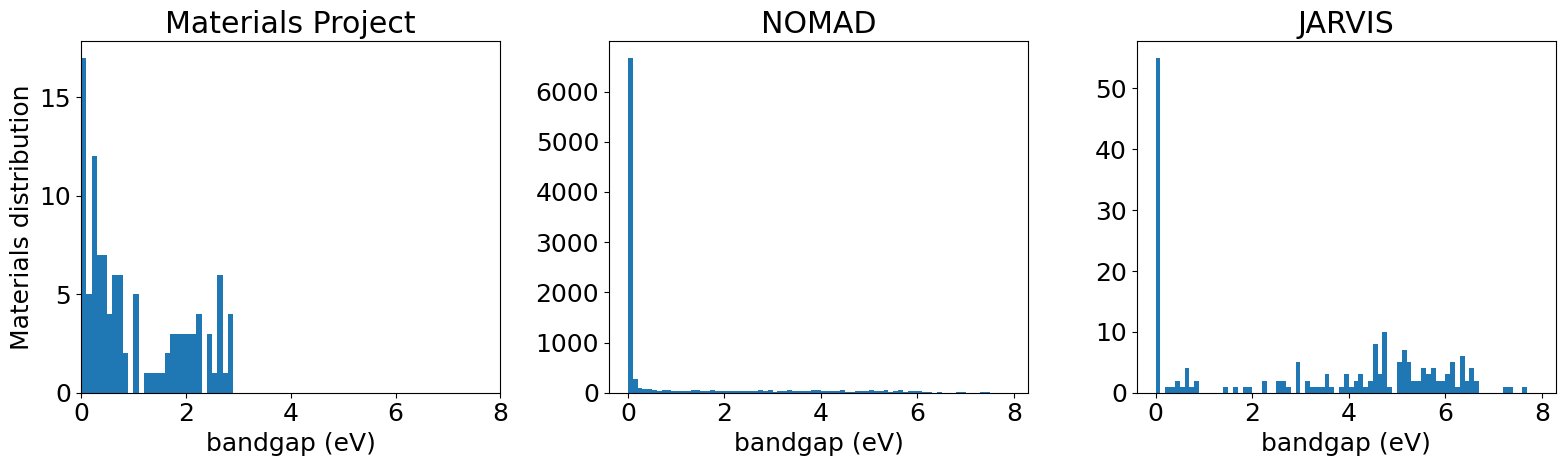

In [85]:
#Create a visualization comparing properties from all sources

the_grid = GridSpec(1, 3)
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(16,5))

plt.subplot(the_grid[0, 0])
val=np.array(dfMP3['bg_MP'].replace('na',np.nan).dropna().values,dtype='float')
plt.hist(val,bins=np.arange(-4,3,.1))
plt.title('Materials Project')
plt.xlabel('bandgap (eV)')
plt.ylabel('Materials distribution')
# Limit X-axis from 0 to 8
plt.xlim(0, 8)

plt.subplot(the_grid[0, 1])
val=np.array(dfNMD['bg_NMD'].replace('na',np.nan).dropna().values,dtype='float')
plt.hist(val,bins=np.arange(0,8,.1))
plt.title('NOMAD')
plt.xlabel('bandgap (eV)')

plt.subplot(the_grid[0, 2])
val=np.array(dfJ['bandgapJARVIS'].replace('na',np.nan).dropna().values,dtype='float')
plt.hist(val,bins=np.arange(0,8,.1))
plt.title('JARVIS')
plt.xlabel('bandgap (eV)')

plt.tight_layout()

In [86]:
#Save merged data you obtained as integrated_dataset.csv
# Saves the DataFrame to your current working directory without the row index
df_merged.to_csv('integrated_dataset.csv', index=False)
